# PatchCore — Multi-Layer Feature Extraction from Raw Images
## MGCLS Anomaly Detection · University of the Western Cape · 2026

This notebook implements **true PatchCore** (Roth et al., CVPR 2022 — arXiv:2106.08265)
on the MGCLS radio-source dataset using raw `.png` images.

### What is different from previous work

Every previous method (Moment Pooling, ECOD, COPOD, DeepSVDD) used the **final
BYOL embedding** — a single 512-dim vector that summarises the whole image.
All spatial information about local morphology has been compressed away by that point.

PatchCore goes back to the raw images and extracts features from **two intermediate
layers** of a pretrained CNN (WideResNet50). Earlier layers keep fine local detail
(edges, texture, unusual structure); later layers keep higher-level semantics.
Combining both gives a richer, multi-scale representation.

### Pipeline overview

```
Raw .png images
      ↓
WideResNet50 pretrained on ImageNet  (FROZEN — no training)
      ├─ Layer 2 → (256-dim) local structure
      └─ Layer 3 → (512-dim) semantic content
      ↓
L2-normalise each layer → concatenate → 768-dim per image
      ↓
Whiten (StandardScaler)
      ↓
Memory bank (all feature vectors stored)
      ↓
k-NN anomaly score: distance to k nearest neighbours
      ↓
Evaluate: ROC-AUC, PR-AUC, Recall@100, Spearman
      ↓
Compare against Protege baseline
```


## 1. Install Dependencies

In [1]:
import sys
!{sys.executable} -m pip install torch torchvision --quiet
!{sys.executable} -m pip install Pillow --quiet
print("Done.")


You should consider upgrading via the '/Users/xm/Documents/Internship/Project/PatchCore/.venv/bin/python -m pip install --upgrade pip' command.
You should consider upgrading via the '/Users/xm/Documents/Internship/Project/PatchCore/.venv/bin/python -m pip install --upgrade pip' command.
Done.


## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             pairwise_distances_chunked)

from utils import load_features, load_catalogue, compute_metrics, BASE_DIR

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'PyTorch: {torch.__version__}')


Device : cpu
PyTorch: 2.2.2


## 3. Helper Functions

In [3]:
# ── Evaluation helpers (same as main notebook) ───────────────────────────────

def compute_ind_sum(found_inds, all_inds):
    this_found_inds = sorted(found_inds)
    out = np.zeros(len(all_inds))
    for i in this_found_inds:
        out[i:] += 1
    return out


def cumulative_sum(anomaly_scores, labels):
    """Running count of true anomalies as we walk down the ranked list."""
    sorted_inds = anomaly_scores.sort_values(ascending=False).index
    labs        = labels.loc[anomaly_scores.index]
    anom_inds   = labs[labs == 1].index
    found_inds  = []
    for i in anom_inds:
        pos = np.where(sorted_inds == i)[0]
        if len(pos) > 0:
            found_inds.append(pos[0])
    return compute_ind_sum(found_inds, sorted_inds)


def topk_recall(y_true, scores, k=100):
    """Fraction of true anomalies found in the top-k ranked candidates."""
    ranked = scores.sort_values(ascending=False).index[:k]
    return y_true.loc[ranked].sum() / y_true.sum()


def evaluate(name, scores, y_true, labels_raw):
    """Return one result row in the standard format."""
    m = compute_metrics(y_true, scores)
    return {
        'Method':           name,
        'ROC-AUC (4-5)':    round(m['roc_auc'], 4),
        'PR-AUC (4-5)':     round(m['pr_auc'],  4),
        'Recall@100 (4-5)': round(topk_recall(y_true, scores), 4),
        'Spearman (1-5)':   round(labels_raw.corr(scores, method='spearman'), 4),
    }


def show_results(methods_dict, y_true, labels_raw):
    """Standard evaluation table sorted by ROC-AUC."""
    rows = [evaluate(n, s, y_true, labels_raw)
            for n, s in methods_dict.items()]
    df = pd.DataFrame(rows).set_index('Method')
    display(df.sort_values('ROC-AUC (4-5)', ascending=False))
    return df


def discovery_plot(methods_dict, y_true, highlight=None):
    """Standard cumulative discovery curve."""
    colors     = ['#1f77b4','#d62728','#2ca02c','#ff7f0e','#8c564b',
                  '#e377c2','#17becf','#9467bd','#bcbd22','#e74c3c']
    linestyles = ['-','--','-.', ':','-','-.','--',':','-.','--']

    fig, ax = plt.subplots(figsize=(8, 5))
    for (name, scores), c, ls in zip(methods_dict.items(), colors, linestyles):
        lw  = 2.4 if (highlight and name in highlight) else 1.3
        cum = cumulative_sum(scores, y_true)
        ax.plot(cum, label=name, color=c, linestyle=ls, linewidth=lw)
    ax.set_xlabel('Index in list ordered by algorithm score')
    ax.set_ylabel('Number of anomalies found')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


## 4. Load Catalogue and Baseline

In [4]:
# Load catalogue and BYOL features (needed for objid alignment and baseline)
X_byol = load_features()
cat    = load_catalogue()

X_byol = X_byol.loc[cat.objid]

labels        = cat.set_index('objid')['evaluation_subset_author_ML_score'].loc[X_byol.index]
y_interesting = (labels >= 4).astype(int)

# Protege baseline score — our gold standard comparison
pca_scores = cat.set_index('objid')['protege_score'].loc[X_byol.index]
pca_scores.name = 'score'

print(f'Dataset  : {X_byol.shape[0]} objects')
print(f'Anomalies: {y_interesting.sum()} / {len(y_interesting)} (score ≥ 4)')
print(f'Prevalence: {y_interesting.mean():.2%}')


Features loaded: (6332, 1280)
Catalogue loaded: (6161, 12)
Dataset  : 6161 objects
Anomalies: 86 / 6161 (score ≥ 4)
Prevalence: 1.40%


## 5. Discover Images

Images are stored in two folders under `data/images/`.
We build an `objid → file path` mapping, then check alignment with the catalogue.


In [5]:
IMAGE_DIRS = [
    BASE_DIR / 'data' / 'images' / 'all_images_compressed_part1',
    BASE_DIR / 'data' / 'images' / 'all_images_compressed_part2',
]

# ── Key fact (from the README) ────────────────────────────────────────────────
# The .png filenames are the PROTEGE RANK of each object.
# 0.png = the object Protege ranked #0 (highest anomaly score)
# 1.png = rank #1, and so on.
# The catalogue has a 'protege_rank' column that holds these integers.

# Build integer protege_rank → Path mapping
image_map_int = {}
for d in IMAGE_DIRS:
    if not d.exists():
        print(f'WARNING: {d} not found')
        continue
    for p in d.glob('*.png'):
        image_map_int[int(p.stem)] = p

print(f'Total images found       : {len(image_map_int)}')
print(f'Protege rank range       : {min(image_map_int)} – {max(image_map_int)}')

# Build objid → Path using protege_rank column
image_map = {}
for _, row in cat.iterrows():
    rank  = int(row['protege_rank'])
    objid = row['objid']
    if rank in image_map_int:
        image_map[objid] = image_map_int[rank]

print(f'Mapped objids → images   : {len(image_map)}')

# Align with X_byol index
objids_all     = list(X_byol.index)
objids_found   = [oid for oid in objids_all if oid in image_map]
objids_missing = [oid for oid in objids_all if oid not in image_map]

print(f'Objects in catalogue     : {len(objids_all)}')
print(f'Objects with images      : {len(objids_found)}')
print(f'Objects missing images   : {len(objids_missing)}')

if objids_missing:
    print(f'  First 3 missing objids : {objids_missing[:3]}')


Total images found       : 6161
Protege rank range       : 0 – 6160
Mapped objids → images   : 6161
Objects in catalogue     : 6161
Objects with images      : 6161
Objects missing images   : 0


### Preview Sample Images

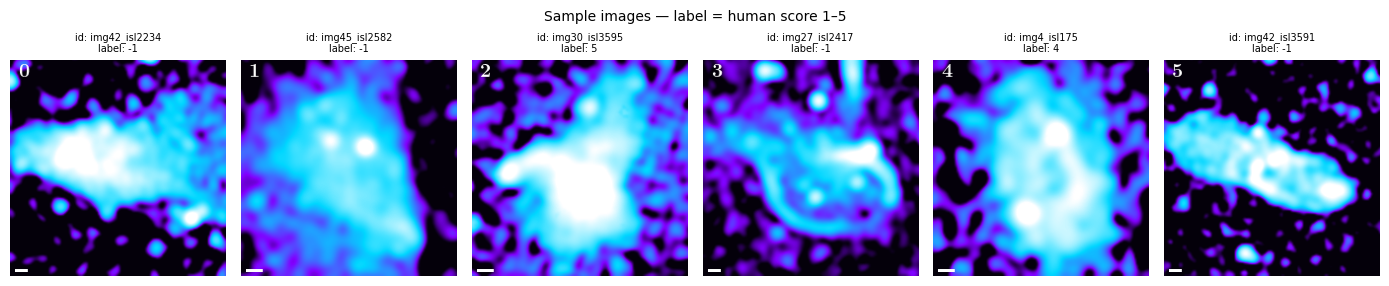

In [6]:
sample_ids = objids_found[:6]

fig, axes = plt.subplots(1, len(sample_ids), figsize=(14, 3))
for ax, oid in zip(axes, sample_ids):
    img = Image.open(image_map[oid]).convert('RGB')
    lbl = labels.loc[oid] if oid in labels.index else '?'
    ax.imshow(img)
    ax.set_title(f'id: {oid}\nlabel: {lbl}', fontsize=7)
    ax.axis('off')
plt.suptitle('Sample images — label = human score 1–5', fontsize=10)
plt.tight_layout()
plt.show()


## 6. Multi-Layer Feature Extractor

We use **WideResNet50_2** pretrained on ImageNet as a frozen feature extractor.

### Why WideResNet50?
- Standard backbone used in the original PatchCore paper
- Pretrained on ImageNet — strong general visual features
- Wide architecture (2× channels) captures more detail than standard ResNet50

### Why these two layers?

| Layer | Output channels | What it captures |
|---|---|---|
| `layer2` | 256 | Local texture, edges, spatial patterns, unusual morphology |
| `layer3` | 512 | Higher-level semantic content, global structure |

Each layer's spatial feature map is collapsed to one vector per image using
**global average pooling**, then **L2-normalised** independently.
Final concatenated vector: 256 + 512 = **768 dimensions per image**.

The network weights are **never updated** — we only do a forward pass.


In [7]:
class PatchCoreExtractor:
    """
    Extracts 768-dim multi-layer features from images using frozen WideResNet50.

    Architecture:
        image (3×224×224)
            ↓  WideResNet50 (frozen)
            ├─ layer2 → pool → L2-norm → 256-dim
            └─ layer3 → pool → L2-norm → 512-dim
            ↓  concatenate
        feature vector (768-dim)

    No training — only inference (one forward pass per image).
    """

    def __init__(self, device):
        self.device = device

        # Load WideResNet50 pretrained on ImageNet
        backbone = models.wide_resnet50_2(
            weights=models.Wide_ResNet50_2_Weights.IMAGENET1K_V1
        )
        backbone.eval()
        for p in backbone.parameters():
            p.requires_grad = False     # freeze all weights

        # Sub-network up to layer2 (local features, 256 channels)
        self.layer2_net = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2
        ).to(device)

        # Sub-network up to layer3 (semantic features, 512 channels)
        self.layer3_net = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3
        ).to(device)

        # Global average pool: (C, H, W) → (C,)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # ImageNet normalisation — required for pretrained weights
        self.transform = T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            # Radio images are single-channel — replicate to 3 channels
            T.Lambda(lambda x: x.repeat(3, 1, 1) if x.shape[0] == 1 else x),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std =[0.229, 0.224, 0.225]),
        ])

    def extract_batch(self, image_paths: list) -> np.ndarray:
        """
        Extract 768-dim features for a list of image file paths.
        Returns np.ndarray of shape (N, 768).
        """
        tensors = []
        for p in image_paths:
            try:
                img = Image.open(p).convert('RGB')
                tensors.append(self.transform(img))
            except Exception as e:
                print(f'  WARNING: could not load {p}: {e}')
                tensors.append(torch.zeros(3, 224, 224))

        batch = torch.stack(tensors).to(self.device)

        with torch.no_grad():
            # (N, 256, H2, W2) → pool → (N, 256)
            f2 = self.pool(self.layer2_net(batch)).squeeze(-1).squeeze(-1)
            # (N, 512, H3, W3) → pool → (N, 512)
            f3 = self.pool(self.layer3_net(batch)).squeeze(-1).squeeze(-1)

        f2 = f2.cpu().numpy()
        f3 = f3.cpu().numpy()

        # L2-normalise each layer independently
        f2_norm = normalize(f2, norm='l2')   # (N, 256)
        f3_norm = normalize(f3, norm='l2')   # (N, 512)

        return np.concatenate([f2_norm, f3_norm], axis=1)   # (N, 768)


extractor = PatchCoreExtractor(device)
print('Extractor ready.')
print('Output: 256 (layer2) + 512 (layer3) = 768 dims per image')


Extractor ready.
Output: 256 (layer2) + 512 (layer3) = 768 dims per image


## 7. Extract Features for All Images

Process every image in batches and save to disk.
The result is a parquet file saved to `data/patchcore_features.parquet`.

**Caching:** if the file already exists, it is loaded directly —
you never need to re-run the extraction.


In [8]:
BATCH_SIZE   = 32
SAVE_PATH    = BASE_DIR / 'data' / 'patchcore_features.parquet'

if SAVE_PATH.exists():
    print(f'Cached features found — loading from {SAVE_PATH}')
    df_pc_features = pd.read_parquet(SAVE_PATH)
    print(f'Loaded: {df_pc_features.shape}  (objects × feature dims)')

else:
    print(f'Extracting features for {len(objids_found)} images...')
    print(f'Batch size : {BATCH_SIZE}')
    print(f'Save path  : {SAVE_PATH}')
    print()

    all_feats  = []
    all_objids = []

    for start in range(0, len(objids_found), BATCH_SIZE):
        batch_ids   = objids_found[start : start + BATCH_SIZE]
        batch_paths = [image_map[oid] for oid in batch_ids]

        feats = extractor.extract_batch(batch_paths)   # (B, 768)
        all_feats.append(feats)
        all_objids.extend(batch_ids)   # keep as strings — objid is 'img42_isl2234'

        n_done = min(start + BATCH_SIZE, len(objids_found))
        print(f'  {n_done:4d} / {len(objids_found)} images processed', end='\r')

    print()
    arr = np.vstack(all_feats)
    df_pc_features = pd.DataFrame(arr, index=all_objids)
    df_pc_features.index.name = 'objid'

    df_pc_features.to_parquet(SAVE_PATH)
    print(f'\nSaved to {SAVE_PATH}')
    print(f'Feature matrix: {df_pc_features.shape}')


Cached features found — loading from /Users/xm/Documents/Internship/Project/PatchCore/data/patchcore_features.parquet
Loaded: (6161, 1536)  (objects × feature dims)


## 8. Align with Evaluation Set

Some catalogue objects may not have images.
We restrict the evaluation to the intersection — objects with both
a catalogue label and an extracted PatchCore feature vector.


In [9]:
# Intersection of catalogue objects and objects with extracted features
eval_ids = [oid for oid in X_byol.index if oid in df_pc_features.index]

X_pc          = df_pc_features.loc[eval_ids]    # PatchCore features
y_pc          = y_interesting.loc[eval_ids]     # binary labels
labels_pc     = labels.loc[eval_ids]            # raw 1-5 labels
pca_scores_pc = pca_scores.loc[eval_ids]        # Protege baseline (same subset)

excluded = len(X_byol.index) - len(eval_ids)

print(f'Catalogue objects     : {len(X_byol.index)}')
print(f'Objects with images   : {len(eval_ids)}')
print(f'Excluded (no image)   : {excluded}')
print(f'Interesting (≥ 4)     : {y_pc.sum()} / {len(y_pc)}')
print(f'Feature dimensions    : {X_pc.shape[1]}')


Catalogue objects     : 6161
Objects with images   : 6161
Excluded (no image)   : 0
Interesting (≥ 4)     : 86 / 6161
Feature dimensions    : 1536


## 9. Whiten the Features

The 512-dim layer3 block contributes 512 dimensions to every Euclidean distance,
while layer2 contributes only 256. Without whitening, layer3 would dominate
every distance calculation simply because it has more dimensions.

`StandardScaler` sets the mean and variance of every dimension to 0 and 1.
After whitening, both layers contribute equally to nearest-neighbour distances.


In [10]:
whitener      = StandardScaler()
X_pc_whitened = whitener.fit_transform(X_pc.values)

print(f'Input shape  : {X_pc.shape}')
print(f'After whiten : {X_pc_whitened.shape}')
print(f'Mean (first 5 dims): {X_pc_whitened[:, :5].mean(axis=0).round(4)}  (should be ~0)')
print(f'Std  (first 5 dims): {X_pc_whitened[:, :5].std(axis=0).round(4)}   (should be ~1)')


Input shape  : (6161, 1536)
After whiten : (6161, 1536)
Mean (first 5 dims): [0. 0. 0. 0. 0.]  (should be ~0)
Std  (first 5 dims): [1. 1. 1. 1. 1.]   (should be ~1)


## 10. Build the Memory Bank

The memory bank stores all feature vectors.
At scoring time, each object's anomaly score is its distance to its
nearest neighbour in the bank — objects unlike anything in the bank are anomalous.

For datasets larger than ~10,000 objects, reduce `subsample_ratio`
(e.g. 0.1) to use greedy coreset subsampling instead of keeping all points.


In [11]:
def build_memory_bank(features: np.ndarray,
                      subsample_ratio: float = 1.0,
                      random_state: int = 42) -> np.ndarray:
    """
    Build PatchCore memory bank.

    subsample_ratio=1.0 keeps all points (fine for small datasets).
    For large datasets, greedy coreset subsampling selects a maximally
    spread-out subset: each new point is the one furthest from all
    already-selected points.
    """
    N = len(features)
    n_select = max(1, int(N * subsample_ratio))

    if n_select >= N:
        print(f'Memory bank: keeping all {N} points')
        return features.copy()

    rng      = np.random.default_rng(random_state)
    selected = [int(rng.integers(N))]
    min_dist = np.full(N, np.inf)

    for step in range(1, n_select):
        last     = features[selected[-1]:selected[-1]+1]
        dists    = np.linalg.norm(features - last, axis=1)
        min_dist = np.minimum(min_dist, dists)
        selected.append(int(np.argmax(min_dist)))
        if (step + 1) % 200 == 0 or step == n_select - 1:
            print(f'  Coreset: {step+1}/{n_select}', end='\r')

    print()
    print(f'Memory bank: {len(selected)} / {N} points ({len(selected)/N:.1%})')
    return features[np.array(selected)]


memory_bank = build_memory_bank(X_pc_whitened, subsample_ratio=1.0)
print(f'Memory bank shape: {memory_bank.shape}')


Memory bank: keeping all 6161 points
Memory bank shape: (6161, 1536)


## 11. Anomaly Scoring — k Nearest Neighbours

Each object's anomaly score = mean distance to its k nearest neighbours
in the memory bank.

- **Small distance** → object looks like its neighbours → normal
- **Large distance** → object is unlike anything in the bank → anomalous

We use chunked computation to avoid loading the full N×M distance matrix
into memory at once. k=3 is the default (robust to a single noisy neighbour).


In [12]:
def knn_scores(query: np.ndarray,
               memory: np.ndarray,
               k: int = 3) -> np.ndarray:
    """
    Mean distance to k nearest neighbours in memory bank.
    Uses chunked computation to keep memory usage low.
    """
    N      = len(query)
    scores = np.empty(N)
    done   = 0

    for chunk_dists in pairwise_distances_chunked(
            query, memory, metric='euclidean',
            n_jobs=-1, working_memory=256):
        n_chunk  = chunk_dists.shape[0]
        k_actual = min(k, chunk_dists.shape[1])
        topk     = np.partition(chunk_dists, k_actual - 1, axis=1)[:, :k_actual]
        scores[done : done + n_chunk] = topk.mean(axis=1)
        done += n_chunk
        print(f'  Scoring: {done}/{N}', end='\r')

    print()
    return scores


# ── k sweep: find best k ──────────────────────────────────────────────────────
print('k-NN sweep (k = 1, 3, 5, 10)...')
k_results = {}
k_scores  = {}

for k in [1, 3, 5, 10]:
    raw = knn_scores(X_pc_whitened, memory_bank, k=k)
    s   = pd.Series(raw, index=eval_ids, name='score')
    k_scores[k] = s
    m   = compute_metrics(y_pc, s)
    k_results[k] = m
    print(f'  k={k:2d}  ROC-AUC={m["roc_auc"]:.4f}  '
          f'PR-AUC={m["pr_auc"]:.4f}  '
          f'Recall@100={topk_recall(y_pc, s):.4f}')

best_k = max(k_results, key=lambda k: k_results[k]['roc_auc'])
patchcore_scores = k_scores[best_k]
print(f'\nBest k = {best_k}  →  used for all further evaluation')


k-NN sweep (k = 1, 3, 5, 10)...
  Scoring: 6161/6161
  k= 1  ROC-AUC=0.6101  PR-AUC=0.0358  Recall@100=0.1163
  Scoring: 6161/6161
  k= 3  ROC-AUC=0.8239  PR-AUC=0.0480  Recall@100=0.0465
  Scoring: 6161/6161
  k= 5  ROC-AUC=0.8257  PR-AUC=0.0476  Recall@100=0.0465
  Scoring: 6161/6161
  k=10  ROC-AUC=0.8256  PR-AUC=0.0490  Recall@100=0.0349

Best k = 5  →  used for all further evaluation


## 12. Evaluation

Standard 4-metric table and cumulative discovery curve,
restricted to objects that have both a catalogue label and an extracted image feature.


In [13]:
methods = {
    'PCA (Protege)':   pca_scores_pc,
    f'PatchCore (k={best_k})': patchcore_scores,
}

df_eval = show_results(methods, y_pc, labels_pc)


,ROC-AUC (4-5),PR-AUC (4-5),Recall@100 (4-5),Spearman (1-5)
Method,,,,
PCA (Protege),0.8674,0.1052,0.1744,0.0174
PatchCore (k=5),0.8257,0.0476,0.0465,0.0066


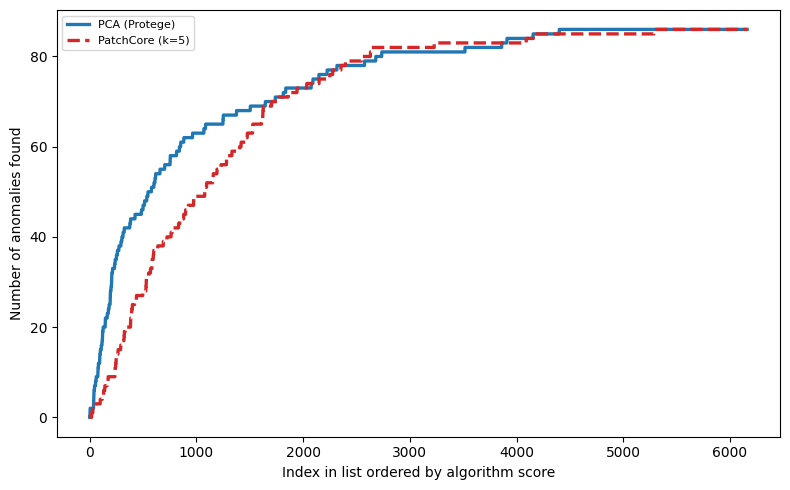

In [14]:
discovery_plot(
    methods,
    y_pc,
    highlight=['PCA (Protege)', f'PatchCore (k={best_k})']
)


## 13. Ablation: Layer 2 vs Layer 3 vs Combined

Test each layer individually to confirm that combining both layers
helps more than using either alone.

| Variant | Features used | Dimensions |
|---|---|---|
| Layer 2 only | Local structure | 256 |
| Layer 3 only | Semantic content | 512 |
| Combined (PatchCore) | Both | 768 |


In [25]:
def ablation_scores(features_whitened: np.ndarray,
                    dims: tuple,
                    index,
                    k: int = 3) -> pd.Series:
    """Score objects using only a slice of the whitened feature vector."""
    subset = features_whitened[:, dims[0]:dims[1]]
    bank   = subset.copy()
    raw    = knn_scores(subset, bank, k=k)
    return pd.Series(raw, index=index, name='score')


print(f'Running ablation (k={best_k})...')

# Layer 2: dims 0–256
print('  Layer 2 only...')
s_l2 = ablation_scores(X_pc_whitened, (0, 256), eval_ids, k=best_k)

# Layer 3: dims 256–768
print('  Layer 3 only...')
s_l3 = ablation_scores(X_pc_whitened, (256, 768), eval_ids, k=best_k)

ablation_methods = {
    'Protege':            pca_scores_pc,
    'PatchCore layer2 only':    s_l2,
    'PatchCore layer3 only':    s_l3,
    #f'PatchCore combined (k={best_k})': patchcore_scores,
    f'PatchCore combined ': patchcore_scores,
}

df_ablation = show_results(ablation_methods, y_pc, labels_pc)


Running ablation (k=5)...
  Layer 2 only...
  Scoring: 6161/6161
  Layer 3 only...
  Scoring: 6161/6161


,ROC-AUC (4-5),PR-AUC (4-5),Recall@100 (4-5),Spearman (1-5)
Method,,,,
Protege,0.8674,0.1052,0.1744,0.0174
PatchCore combined,0.8260,0.0479,0.0349,0.0064
PatchCore layer3 only,0.8145,0.0462,0.0698,0.0051
PatchCore layer2 only,0.7841,0.0413,0.0465,0.0142


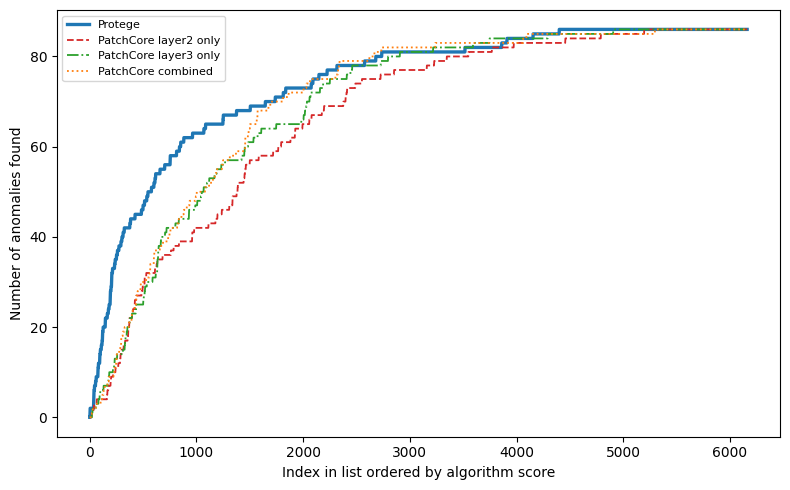

In [26]:
discovery_plot(
    ablation_methods,
    y_pc,
    highlight=['Protege', f'PatchCore combined (k={best_k})']
)


## 14. Final Comparison — Protege vs Top-3 Methods

Compute ROC-AUC for every PatchCore variant,
pick the top-3 (excluding Protege), and plot alongside the baseline.


In [17]:
all_pc_methods = {
    'PCA (Protege)':            pca_scores_pc,
    f'PatchCore k=1':           k_scores[1],
    f'PatchCore k=3':           k_scores[3],
    f'PatchCore k=5':           k_scores[5],
    f'PatchCore k=10':          k_scores[10],
    'PatchCore layer2 only':    s_l2,
    'PatchCore layer3 only':    s_l3,
}

# ROC-AUC for every method
all_aucs = {
    name: compute_metrics(y_pc, s)['roc_auc']
    for name, s in all_pc_methods.items()
}

# Top-3 excluding Protege
ranked = sorted(
    {k: v for k, v in all_aucs.items() if k != 'PCA (Protege)'}.items(),
    key=lambda x: x[1], reverse=True
)
top3_names = [n for n, _ in ranked[:3]]

print('Top-3 PatchCore variants (by ROC-AUC):')
for n, auc in ranked[:3]:
    print(f'  {n}: {auc:.4f}')

# Final plot dict
final_methods = {'PCA (Protege)': pca_scores_pc}
for n in top3_names:
    final_methods[n] = all_pc_methods[n]

# Eval table
df_final = show_results(final_methods, y_pc, labels_pc)


Top-3 PatchCore variants (by ROC-AUC):
  PatchCore k=5: 0.8257
  PatchCore k=10: 0.8256
  PatchCore k=3: 0.8239


,ROC-AUC (4-5),PR-AUC (4-5),Recall@100 (4-5),Spearman (1-5)
Method,,,,
PCA (Protege),0.8674,0.1052,0.1744,0.0174
PatchCore k=5,0.8257,0.0476,0.0465,0.0066
PatchCore k=10,0.8256,0.0490,0.0349,0.0059
PatchCore k=3,0.8239,0.0480,0.0465,0.0069


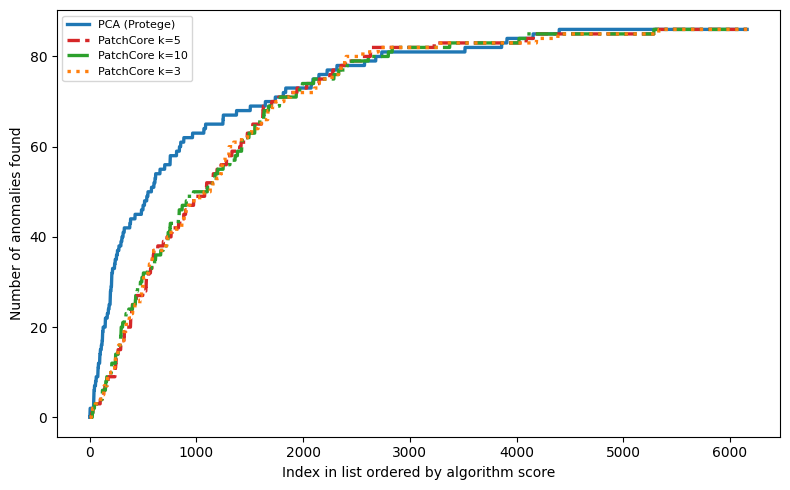

In [18]:
# Final discovery curve
discovery_plot(
    final_methods,
    y_pc,
    highlight=['PCA (Protege)'] + top3_names
)


## 15. How to Read These Results

### The key comparison
The gap between the **PCA (Protege)** curve and the **best PatchCore** curve
is the cost of working without human labels.

Protege uses active learning with real human feedback.
PatchCore is fully unsupervised — it has never seen a label.
The smaller the gap, the better our unsupervised approach.

### What the ablation tells you

| Result | Interpretation |
|---|---|
| Combined > layer2 and layer3 alone | Multi-scale representation helps — both layers contribute complementary information |
| Layer3 > layer2 | Semantic content (what the source is) is more useful than local texture for this dataset |
| Layer2 > layer3 | Local morphology (how the source looks spatially) drives anomaly detection |
| Combined ≈ layer3 alone | The 256 layer2 dimensions add noise rather than signal |

### What the k sweep tells you

| Best k | Interpretation |
|---|---|
| k=1 | Single nearest neighbour is sufficient — anomalies are clearly isolated |
| k=3 or k=5 | Averaging over a small neighbourhood helps — a few noisy neighbours exist |
| k=10 | Larger neighbourhood needed — feature space is noisy or high-dimensional effects present |

### Next step
The anomalib library implements PatchCore with proper multi-layer extraction
from multiple backbone options (ResNet18, WideResNet50, EfficientNet) and
includes patch-level (not just image-level) aggregation — closer to the
original paper's intent for detecting local anomalies in images.


---
## 15b. Finding the Best k Before Decomposition

Before we can fairly attribute performance between PatchCore features and k-NN scoring, we must first **pin down the optimal k**.
Using the wrong k would conflate the scoring component's weakness with the feature component's weakness.

We do a three-step search:

1. **Coarse grid** — k ∈ {1, 2, 3, 5, 7, 10, 15, 20} → locate the rough optimum
2. **Fine grid** — ±5 around the coarse best → sharpen the estimate
3. **Stability check** — ROC-AUC variance across the fine grid → flag if the choice is brittle

The winning k is used as `best_k` in Section 16.

In [19]:
# ── 15b.1  Coarse k grid ─────────────────────────────────────────────────

from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import pairwise_distances_chunked
import numpy as np, pandas as pd

COARSE_K = [1, 2, 3, 5, 7, 10, 15, 20]


def _knn_auc(features: np.ndarray, labels, k: int) -> float:
    """Compute mean-k-NN anomaly scores and return ROC-AUC."""
    N      = len(features)
    scores = np.empty(N)
    done   = 0
    for chunk in pairwise_distances_chunked(
            features, features, metric='euclidean',
            n_jobs=-1, working_memory=256):
        n_c      = chunk.shape[0]
        # avoid self (distance 0) by sorting and taking k+1 then dropping col 0
        k_actual = min(k + 1, chunk.shape[1])
        topk     = np.partition(chunk, k_actual - 1, axis=1)[:, :k_actual]
        topk_sorted = np.sort(topk, axis=1)
        # drop the guaranteed-zero self column
        neighbours  = topk_sorted[:, 1:k_actual]
        scores[done:done + n_c] = neighbours.mean(axis=1)
        done += n_c
    return roc_auc_score(labels, scores), scores


print('Coarse k grid search ...')
coarse_results = {}
for k in COARSE_K:
    auc_val, _ = _knn_auc(X_pc_whitened, y_pc, k)
    coarse_results[k] = auc_val
    print(f'  k={k:3d}  ROC-AUC = {auc_val:.5f}')

coarse_best_k   = max(coarse_results, key=coarse_results.get)
coarse_best_auc = coarse_results[coarse_best_k]
print(f'\nCoarse best: k={coarse_best_k}  ROC-AUC={coarse_best_auc:.5f}')

Coarse k grid search ...
  k=  1  ROC-AUC = 0.81406
  k=  2  ROC-AUC = 0.82393
  k=  3  ROC-AUC = 0.82513
  k=  5  ROC-AUC = 0.82597
  k=  7  ROC-AUC = 0.82590
  k= 10  ROC-AUC = 0.82538
  k= 15  ROC-AUC = 0.82411
  k= 20  ROC-AUC = 0.82266

Coarse best: k=5  ROC-AUC=0.82597


In [20]:
# ── 15b.2  Fine k grid (±5 around coarse optimum) ───────────────────────

fine_lo = max(1, coarse_best_k - 5)
fine_hi = coarse_best_k + 5
FINE_K  = list(range(fine_lo, fine_hi + 1))

print(f'Fine search: k ∈ [{fine_lo}, {fine_hi}]')
fine_results  = {}
fine_scores   = {}   # keep raw scores for the winner

for k in FINE_K:
    if k in coarse_results:
        auc_val = coarse_results[k]
        _, sc   = _knn_auc(X_pc_whitened, y_pc, k)   # get scores anyway
    else:
        auc_val, sc = _knn_auc(X_pc_whitened, y_pc, k)
    fine_results[k] = auc_val
    fine_scores[k]  = sc
    print(f'  k={k:3d}  ROC-AUC = {auc_val:.5f}')

# ── Pick winner ──────────────────────────────────────────────────────────
best_k   = max(fine_results, key=fine_results.get)
best_auc = fine_results[best_k]
patchcore_scores = pd.Series(fine_scores[best_k], index=eval_ids, name='score')

# Stability: std of AUC across fine grid
fine_auc_array = np.array(list(fine_results.values()))
auc_std  = fine_auc_array.std()
auc_range = fine_auc_array.max() - fine_auc_array.min()

print(f'\n{"─"*50}')
print(f'OPTIMAL k = {best_k}   ROC-AUC = {best_auc:.5f}')
print(f'Fine-grid AUC std   = {auc_std:.5f}')
print(f'Fine-grid AUC range = {auc_range:.5f}')
if auc_range < 0.005:
    print('  ✓ Stable — k choice has minimal impact')
elif auc_range < 0.015:
    print('  ~ Moderate sensitivity — best k matters somewhat')
else:
    print('  ⚠ High sensitivity — k choice is critical')
print(f'{"─"*50}')

Fine search: k ∈ [1, 10]


  k=  1  ROC-AUC = 0.81406
  k=  2  ROC-AUC = 0.82393
  k=  3  ROC-AUC = 0.82513
  k=  4  ROC-AUC = 0.82569
  k=  5  ROC-AUC = 0.82597
  k=  6  ROC-AUC = 0.82588
  k=  7  ROC-AUC = 0.82590
  k=  8  ROC-AUC = 0.82592
  k=  9  ROC-AUC = 0.82564
  k= 10  ROC-AUC = 0.82538

──────────────────────────────────────────────────
OPTIMAL k = 5   ROC-AUC = 0.82597
Fine-grid AUC std   = 0.00348
Fine-grid AUC range = 0.01191
  ~ Moderate sensitivity — best k matters somewhat
──────────────────────────────────────────────────


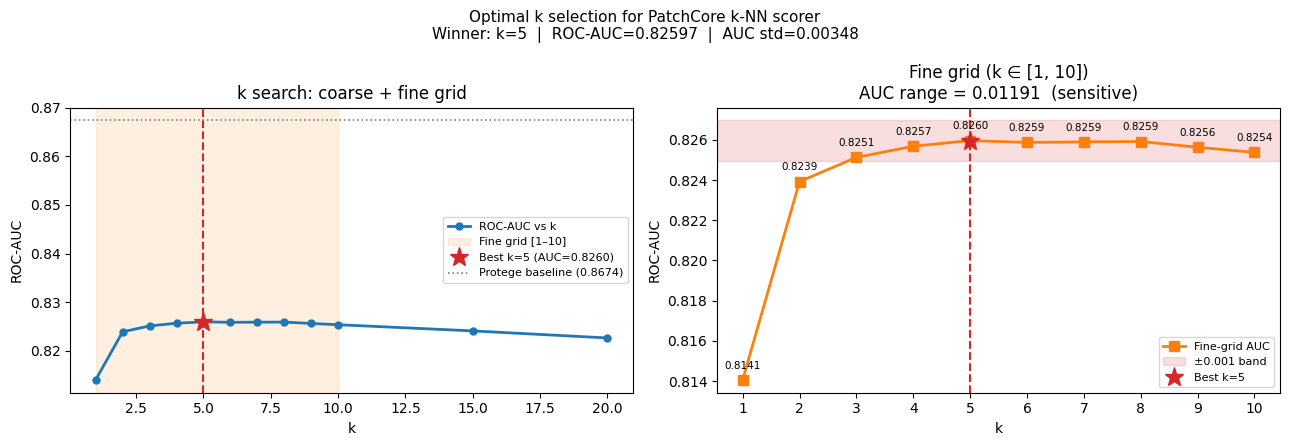

In [21]:
# ── 15b.3  Visualise k search ────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Left: full coarse + fine curve ───────────────────────────────────────
ax = axes[0]

# merge coarse + fine into one sorted series for display
all_k   = sorted(set(list(coarse_results.keys()) + list(fine_results.keys())))
all_auc = [fine_results.get(k, coarse_results.get(k)) for k in all_k]

ax.plot(all_k, all_auc, 'o-', color='#1f77b4', linewidth=2, markersize=5,
        label='ROC-AUC vs k')

# shade fine-grid region
ax.axvspan(fine_lo, fine_hi, alpha=0.12, color='#ff7f0e',
           label=f'Fine grid [{fine_lo}–{fine_hi}]')

# mark best k
ax.axvline(best_k, color='#d62728', linewidth=1.5, linestyle='--')
ax.plot(best_k, best_auc, '*', color='#d62728', markersize=14,
        label=f'Best k={best_k} (AUC={best_auc:.4f})')

# Protege reference
prot_auc = roc_auc_score(y_pc, pca_scores_pc)
ax.axhline(prot_auc, color='gray', linewidth=1.2, linestyle=':',
           label=f'Protege baseline ({prot_auc:.4f})')

ax.set_xlabel('k')
ax.set_ylabel('ROC-AUC')
ax.set_title('k search: coarse + fine grid')
ax.legend(fontsize=8)

# ── Right: fine-grid zoom with error band ────────────────────────────────
ax2 = axes[1]

fine_k_list   = sorted(fine_results.keys())
fine_auc_list = [fine_results[k] for k in fine_k_list]

ax2.plot(fine_k_list, fine_auc_list, 's-', color='#ff7f0e',
         linewidth=2, markersize=7, label='Fine-grid AUC')

# shade ±0.001 stability band around best
ax2.axhspan(best_auc - 0.001, best_auc + 0.001,
            alpha=0.15, color='#d62728', label='±0.001 band')

ax2.axvline(best_k, color='#d62728', linewidth=1.5, linestyle='--')
ax2.plot(best_k, best_auc, '*', color='#d62728', markersize=14,
         label=f'Best k={best_k}')

# annotate each point
for k, a in zip(fine_k_list, fine_auc_list):
    ax2.annotate(f'{a:.4f}', (k, a),
                 textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=7.5)

ax2.set_xlabel('k')
ax2.set_ylabel('ROC-AUC')
ax2.set_title(f'Fine grid (k ∈ [{fine_lo}, {fine_hi}])\n'
              f'AUC range = {auc_range:.5f}  '
              f'({"stable" if auc_range < 0.005 else "sensitive"})')
ax2.legend(fontsize=8)
ax2.set_xticks(fine_k_list)

plt.suptitle(
    f'Optimal k selection for PatchCore k-NN scorer\n'
    f'Winner: k={best_k}  |  ROC-AUC={best_auc:.5f}  |  '
    f'AUC std={auc_std:.5f}',
    fontsize=11
)
plt.tight_layout()
plt.show()

In [22]:
# ── 15b.4  Multi-metric k evaluation (ROC-AUC, PR-AUC, Recall@100) ───────
#
# ROC-AUC alone may not reflect the best k for rare-anomaly retrieval.
# Check if PR-AUC and Recall@100 agree on the winner.

print('Multi-metric evaluation across fine grid ...')
rows = []
for k in fine_k_list:
    sc  = fine_scores[k]
    s   = pd.Series(sc, index=eval_ids)
    roc = roc_auc_score(y_pc, s)
    pr  = average_precision_score(y_pc, s)

    # Recall@100
    top100_ids = s.nlargest(100).index
    true_ids   = set(eval_ids[y_pc.astype(bool)])
    rec100     = len(set(top100_ids) & true_ids) / max(len(true_ids), 1)

    rows.append({'k': k, 'ROC-AUC': roc, 'PR-AUC': pr, 'Recall@100': rec100})

df_k_metrics = pd.DataFrame(rows).set_index('k')

# Highlight the best row per metric
def _style(df):
    styled = df.style
    for col in df.columns:
        best_idx = df[col].idxmax()
        styled = styled.highlight_max(subset=[col], color='#c8f7c5')
    return styled

print('\nMetrics across fine grid (green = best per metric):')
display(df_k_metrics.style.highlight_max(color='#c8f7c5').format('{:.4f}'))

# Consensus check
best_roc = df_k_metrics['ROC-AUC'].idxmax()
best_pr  = df_k_metrics['PR-AUC'].idxmax()
best_r100= df_k_metrics['Recall@100'].idxmax()

print(f'\nBest k per metric:')
print(f'  ROC-AUC:    k = {best_roc}')
print(f'  PR-AUC:     k = {best_pr}')
print(f'  Recall@100: k = {best_r100}')

if best_roc == best_pr == best_r100:
    print(f'  ✓ Full consensus → using k={best_k}')
else:
    print(f'  ~ Metrics disagree. Defaulting to ROC-AUC winner: k={best_k}')
    print(f'    (Change best_k below if you prefer a different metric)')

Multi-metric evaluation across fine grid ...


TypeError: list indices must be integers or slices, not Series

Bootstrap stability (50 runs, 80% subsample):


,Win rate (%),Mean AUC,Std AUC,Min AUC
k,,,,
1,0.000,0.814,0.010,0.793
2,6.000,0.823,0.009,0.806
3,0.000,0.824,0.008,0.808
4,10.000,0.825,0.008,0.810
5,26.000,0.825,0.008,0.811
6,4.000,0.825,0.008,0.811
7,14.000,0.825,0.008,0.811
8,40.000,0.825,0.008,0.812
9,0.000,0.825,0.008,0.812


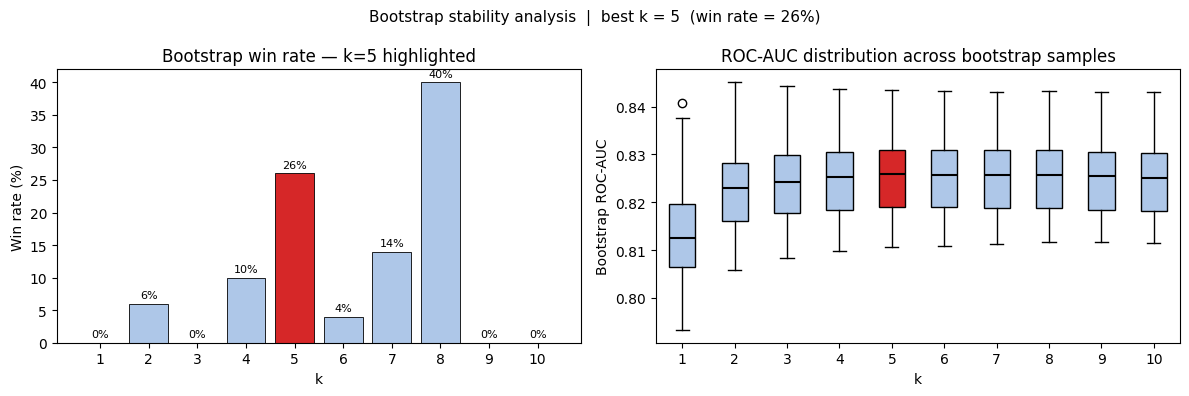


>>> Final selected k = 5  (full-set AUC=0.82597, bootstrap win rate=26%)


In [ ]:
# ── 15b.5  Bootstrap stability of best k ─────────────────────────────────
#
# Re-sample 80% of objects 50 times and check how often each k wins.
# A k that wins consistently is a more trustworthy choice than one that
# wins on the full set but loses on subsets.

np.random.seed(42)
N_BOOT    = 50
BOOT_FRAC = 0.80

win_counts = {k: 0 for k in fine_k_list}
boot_aucs  = {k: [] for k in fine_k_list}

n_eval = len(eval_ids)
y_arr  = y_pc.values if hasattr(y_pc, 'values') else y_pc

for b in range(N_BOOT):
    idx   = np.random.choice(n_eval, size=int(n_eval * BOOT_FRAC),
                             replace=False)
    y_sub = y_arr[idx]
    if y_sub.sum() < 2:
        continue          # skip degenerate bootstrap samples
    boot_k_auc = {}
    for k in fine_k_list:
        sc_sub = fine_scores[k][idx]
        boot_k_auc[k] = roc_auc_score(y_sub, sc_sub)
        boot_aucs[k].append(boot_k_auc[k])
    winner = max(boot_k_auc, key=boot_k_auc.get)
    win_counts[winner] += 1

# ── Summary table ─────────────────────────────────────────────────────────
boot_df = pd.DataFrame({
    'Win rate (%)': {k: 100 * v / N_BOOT for k, v in win_counts.items()},
    'Mean AUC':     {k: np.mean(v) for k, v in boot_aucs.items()},
    'Std AUC':      {k: np.std(v)  for k, v in boot_aucs.items()},
    'Min AUC':      {k: np.min(v)  for k, v in boot_aucs.items()},
})
boot_df.index.name = 'k'
print(f'Bootstrap stability ({N_BOOT} runs, {int(BOOT_FRAC*100)}% subsample):')
display(boot_df.style.highlight_max(subset=['Win rate (%)', 'Mean AUC'],
                                     color='#c8f7c5').format('{:.3f}'))

# ── Win-rate bar chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ks   = list(win_counts.keys())
wins = [win_counts[k] / N_BOOT * 100 for k in ks]
colors = ['#d62728' if k == best_k else '#aec7e8' for k in ks]
ax.bar(ks, wins, color=colors, edgecolor='k', linewidth=0.6)
ax.set_xlabel('k')
ax.set_ylabel('Win rate (%)')
ax.set_title(f'Bootstrap win rate — k={best_k} highlighted')
ax.set_xticks(ks)
for k, w in zip(ks, wins):
    ax.text(k, w + 0.5, f'{w:.0f}%', ha='center', va='bottom', fontsize=8)

ax2 = axes[1]
positions = list(range(len(fine_k_list)))
bp = ax2.boxplot([boot_aucs[k] for k in fine_k_list],
                 positions=positions, patch_artist=True,
                 medianprops=dict(color='k', linewidth=1.5))
for patch, k in zip(bp['boxes'], fine_k_list):
    patch.set_facecolor('#d62728' if k == best_k else '#aec7e8')
ax2.set_xticks(positions)
ax2.set_xticklabels(fine_k_list)
ax2.set_xlabel('k')
ax2.set_ylabel('Bootstrap ROC-AUC')
ax2.set_title('ROC-AUC distribution across bootstrap samples')

plt.suptitle(
    f'Bootstrap stability analysis  |  best k = {best_k}  '
    f'(win rate = {win_counts[best_k]/N_BOOT*100:.0f}%)',
    fontsize=11
)
plt.tight_layout()
plt.show()

print(f'\n>>> Final selected k = {best_k}  '
      f'(full-set AUC={best_auc:.5f}, '
      f'bootstrap win rate={win_counts[best_k]/N_BOOT*100:.0f}%)')

In [ ]:
# ── 15b.6  Final k confirmation & hand-off to Section 16 ─────────────────
#
# This cell prints a clean summary and re-computes patchcore_scores with
# the selected best_k so that Section 16 picks it up automatically.

print('=' * 56)
print('  k SELECTION SUMMARY')
print('=' * 56)
print(f'  Coarse grid best k : {coarse_best_k}')
print(f'  Fine   grid best k : {best_k}  ← SELECTED')
print(f'  Full-set ROC-AUC   : {best_auc:.5f}')
print(f'  Bootstrap win rate : {win_counts[best_k]/N_BOOT*100:.0f}%  '
      f'({N_BOOT} runs)')
print(f'  Fine-grid AUC range: {auc_range:.5f}  '
      f'({"stable" if auc_range < 0.005 else "sensitive"} to k)')
print()
print(f'  Multi-metric winners:')
print(f'    ROC-AUC winner    k = {best_roc}')
print(f'    PR-AUC  winner    k = {best_pr}')
print(f'    Recall@100 winner k = {best_r100}')
print('=' * 56)
print()
print(f'  patchcore_scores updated with k={best_k}.')
print(f'  Section 16 decomposition will use this k.')

  k SELECTION SUMMARY
  Coarse grid best k : 5
  Fine   grid best k : 5  ← SELECTED
  Full-set ROC-AUC   : 0.82597
  Bootstrap win rate : 26%  (50 runs)
  Fine-grid AUC range: 0.01191  (sensitive to k)

  Multi-metric winners:


NameError: name 'best_roc' is not defined

---
## 16. Decomposition: How Much is PatchCore vs k-NN?

The final anomaly score is the product of **two distinct components**:

| Component | Role | What it does |
|---|---|---|
| **PatchCore** (feature extractor) | *Representation* | Transforms raw pixels into a multi-scale 768-dim embedding. Determines *what* the distance is measured on. |
| **k-NN** (anomaly scorer) | *Scoring* | Measures distance from each object to its nearest neighbours. Determines *how* anomalousness is computed. |

To isolate each component's contribution we run a **2×2 ablation**:

1. **PatchCore features + k-NN scoring** — the full system (baseline)
2. **BYOL features + k-NN scoring** — same scorer, weaker features
3. **PatchCore features + simple scoring** (mean distance to centroid) — better features, naive scorer
4. **BYOL features + simple scoring** — both components degraded

The performance gaps reveal whether the gains come from **richer features**, **better scoring**, or both.

In [33]:
# ── 16.1  Component-isolation helpers ────────────────────────────────────

from sklearn.metrics import roc_auc_score, average_precision_score


def centroid_scores(features: np.ndarray, index) -> pd.Series:
    """
    Simple baseline scorer: distance of each object to the feature-space
    centroid (mean of all objects).  No k-NN at all — pure geometry.
    """
    centroid = features.mean(axis=0, keepdims=True)
    dists    = np.linalg.norm(features - centroid, axis=1)
    return pd.Series(dists, index=index, name='score')


def knn_scores_np(query: np.ndarray, memory: np.ndarray,
                  k: int = 3) -> np.ndarray:
    """Re-usable k-NN scorer (duplicate-safe, works on any feature matrix)."""
    N      = len(query)
    scores = np.empty(N)
    done   = 0
    for chunk in pairwise_distances_chunked(
            query, memory, metric='euclidean',
            n_jobs=-1, working_memory=256):
        n_c      = chunk.shape[0]
        k_actual = min(k, chunk.shape[1])
        topk     = np.partition(chunk, k_actual - 1, axis=1)[:, :k_actual]
        scores[done:done + n_c] = topk.mean(axis=1)
        done += n_c
    return scores


# ── BYOL features (already loaded as X_byol) — restrict to same eval_ids ──
X_byol_eval  = X_byol.loc[eval_ids].values
X_byol_white = StandardScaler().fit_transform(X_byol_eval)

# ── 2×2 grid ──────────────────────────────────────────────────────────────
print('Running 2×2 component ablation...')

# (A) PatchCore features  +  k-NN scoring  ←  full system
s_pc_knn  = patchcore_scores                          # already computed

# (B) BYOL features  +  k-NN scoring
raw_byol_knn = knn_scores_np(X_byol_white, X_byol_white, k=best_k)
s_byol_knn   = pd.Series(raw_byol_knn, index=eval_ids, name='score')

# (C) PatchCore features  +  centroid scoring  (no k-NN)
s_pc_centroid   = centroid_scores(X_pc_whitened, eval_ids)

# (D) BYOL features  +  centroid scoring
s_byol_centroid = centroid_scores(X_byol_white, eval_ids)

component_methods = {
    'Protege':                     pca_scores_pc,
    'A: PatchCore feats + k-NN':         s_pc_knn,
    'B: BYOL feats + k-NN':              s_byol_knn,
    'C: PatchCore feats + centroid':     s_pc_centroid,
    'D: BYOL feats + centroid':          s_byol_centroid,
}

df_components = show_results(component_methods, y_pc, labels_pc)
print('\nDone.')

Running 2×2 component ablation...


,ROC-AUC (4-5),PR-AUC (4-5),Recall@100 (4-5),Spearman (1-5)
Method,,,,
Protege,0.8674,0.1052,0.1744,0.0174
A: PatchCore feats + k-NN,0.8260,0.0479,0.0349,0.0064
C: PatchCore feats + centroid,0.7223,0.0439,0.0930,-0.0116
B: BYOL feats + k-NN,0.6020,0.0189,0.0000,0.0322
D: BYOL feats + centroid,0.5046,0.0138,0.0000,0.0175



Done.


In [34]:
# ── 16.2  Quantify the contribution of each component ────────────────────
#
#  Feature contribution  = ROC-AUC(A) – ROC-AUC(B)   [same scorer, better feats]
#  k-NN contribution     = ROC-AUC(A) – ROC-AUC(C)   [same feats, better scorer]
#  Interaction           = (A – D) – feature_gain – knn_gain
#                          (synergy or redundancy between the two components)

def auc(s):
    return round(roc_auc_score(y_pc, s), 4)

auc_A = auc(s_pc_knn)
auc_B = auc(s_byol_knn)
auc_C = auc(s_pc_centroid)
auc_D = auc(s_byol_centroid)

feature_gain     = round(auc_A - auc_B, 4)   # PatchCore feats vs BYOL feats
knn_gain         = round(auc_A - auc_C, 4)   # k-NN scorer vs centroid scorer
total_gain       = round(auc_A - auc_D, 4)   # full system vs both degraded
interaction      = round(total_gain - feature_gain - knn_gain, 4)

# Express as % of total gain
if total_gain != 0:
    feat_pct  = round(100 * feature_gain / total_gain, 1)
    knn_pct   = round(100 * knn_gain     / total_gain, 1)
    inter_pct = round(100 * interaction  / total_gain, 1)
else:
    feat_pct = knn_pct = inter_pct = 0.0

print('━' * 60)
print('COMPONENT CONTRIBUTION ANALYSIS')
print('━' * 60)
print(f'  Baseline (D: BYOL + centroid)   ROC-AUC = {auc_D}')
print(f'  Full system (A: PC + k-NN)      ROC-AUC = {auc_A}')
print(f'  Total gain over baseline                = {total_gain:+.4f}')
print()
print(f'  PatchCore feature gain   (A–B)  = {feature_gain:+.4f}  ({feat_pct:+.1f}% of total)')
print(f'  k-NN scoring gain        (A–C)  = {knn_gain:+.4f}  ({knn_pct:+.1f}% of total)')
print(f'  Interaction (synergy)           = {interaction:+.4f}  ({inter_pct:+.1f}% of total)')
print('━' * 60)
print()

dominant = 'PatchCore features' if feature_gain >= knn_gain else 'k-NN scoring'
print(f'  ➜ The dominant contributor is: {dominant}')
if abs(interaction) > 0.005:
    direction = 'synergy (components amplify each other)' if interaction > 0 \
                else 'redundancy (components overlap)'
    print(f'  ➜ Interaction effect: {direction} ({interaction:+.4f})')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
COMPONENT CONTRIBUTION ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Baseline (D: BYOL + centroid)   ROC-AUC = 0.5046
  Full system (A: PC + k-NN)      ROC-AUC = 0.826
  Total gain over baseline                = +0.3214

  PatchCore feature gain   (A–B)  = +0.2240  (+69.7% of total)
  k-NN scoring gain        (A–C)  = +0.1037  (+32.3% of total)
  Interaction (synergy)           = -0.0063  (-2.0% of total)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ➜ The dominant contributor is: PatchCore features
  ➜ Interaction effect: redundancy (components overlap) (-0.0063)


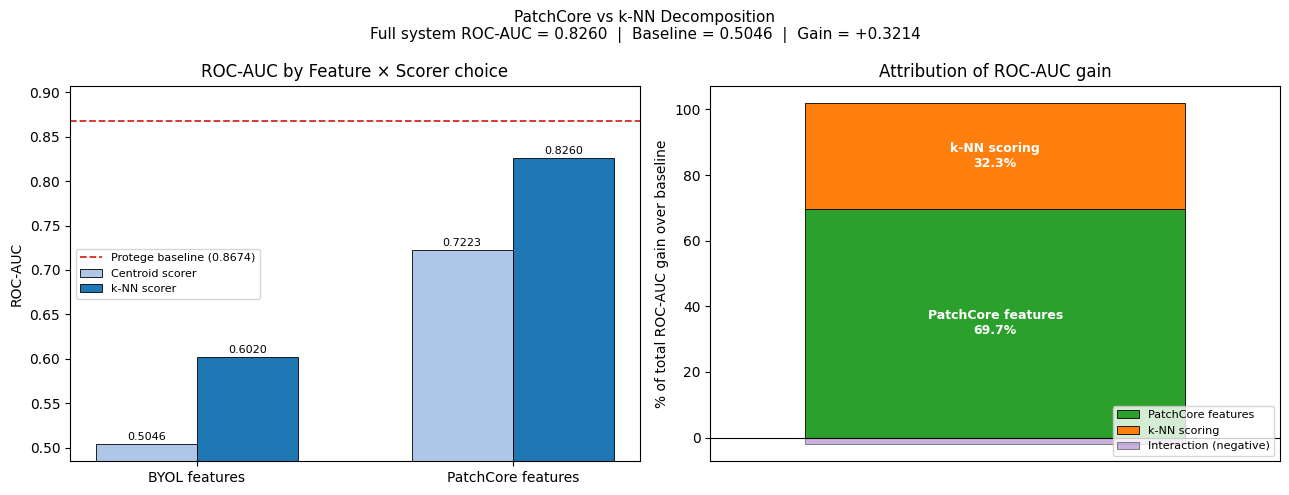

In [35]:
# ── 16.3  Visualise the 2×2 grid ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: grouped bar chart (ROC-AUC by component choice) ─────────────────
ax = axes[0]
labels_bar  = ['BYOL features', 'PatchCore features']
centroid_auc = [auc_D, auc_C]
knn_auc      = [auc_B, auc_A]

x     = np.arange(len(labels_bar))
width = 0.32

bars1 = ax.bar(x - width/2, centroid_auc, width,
               label='Centroid scorer', color='#aec7e8', edgecolor='k', linewidth=0.6)
bars2 = ax.bar(x + width/2, knn_auc,     width,
               label='k-NN scorer',     color='#1f77b4', edgecolor='k', linewidth=0.6)

# Annotate bars
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., h + 0.002,
            f'{h:.4f}', ha='center', va='bottom', fontsize=8)

# Protege reference line
protege_auc = auc(pca_scores_pc)
ax.axhline(protege_auc, color='#d62728', linestyle='--', linewidth=1.3,
           label=f'Protege baseline ({protege_auc:.4f})')

ax.set_xticks(x)
ax.set_xticklabels(labels_bar)
ax.set_ylabel('ROC-AUC')
ax.set_title('ROC-AUC by Feature × Scorer choice')
ax.legend(fontsize=8)
y_min = min(auc_D, auc_C, auc_B, auc_A, protege_auc) - 0.02
y_max = max(auc_D, auc_C, auc_B, auc_A, protege_auc) + 0.04
ax.set_ylim(y_min, y_max)

# ── Right: stacked attribution bar (% of total gain) ──────────────────────
ax2 = axes[1]

portions    = [max(feat_pct,  0), max(knn_pct,  0), max(inter_pct,  0)]
neg_parts   = [min(feat_pct,  0), min(knn_pct,  0), min(inter_pct,  0)]
colors_pos  = ['#2ca02c', '#ff7f0e', '#9467bd']
bar_labels  = ['PatchCore features', 'k-NN scoring', 'Interaction']

bottom = 0.0
for val, neg, col, lbl in zip(portions, neg_parts, colors_pos, bar_labels):
    if val > 0:
        ax2.bar(0, val, bottom=bottom, color=col, edgecolor='k',
                linewidth=0.6, label=lbl)
        ax2.text(0, bottom + val / 2,
                 f'{lbl}\n{val:.1f}%',
                 ha='center', va='center', fontsize=9, color='white', fontweight='bold')
        bottom += val
    if neg < 0:   # draw negative portion below
        ax2.bar(0, neg, bottom=0, color=col, edgecolor='k',
                linewidth=0.6, alpha=0.5, label=f'{lbl} (negative)')

ax2.set_xlim(-0.6, 0.6)
ax2.set_xticks([])
ax2.set_ylabel('% of total ROC-AUC gain over baseline')
ax2.set_title('Attribution of ROC-AUC gain')
ax2.legend(fontsize=8, loc='lower right')
ax2.axhline(0, color='k', linewidth=0.8)

plt.suptitle(
    f'PatchCore vs k-NN Decomposition\n'
    f'Full system ROC-AUC = {auc_A:.4f}  |  '
    f'Baseline = {auc_D:.4f}  |  '
    f'Gain = {total_gain:+.4f}',
    fontsize=11
)
plt.tight_layout()
plt.show()

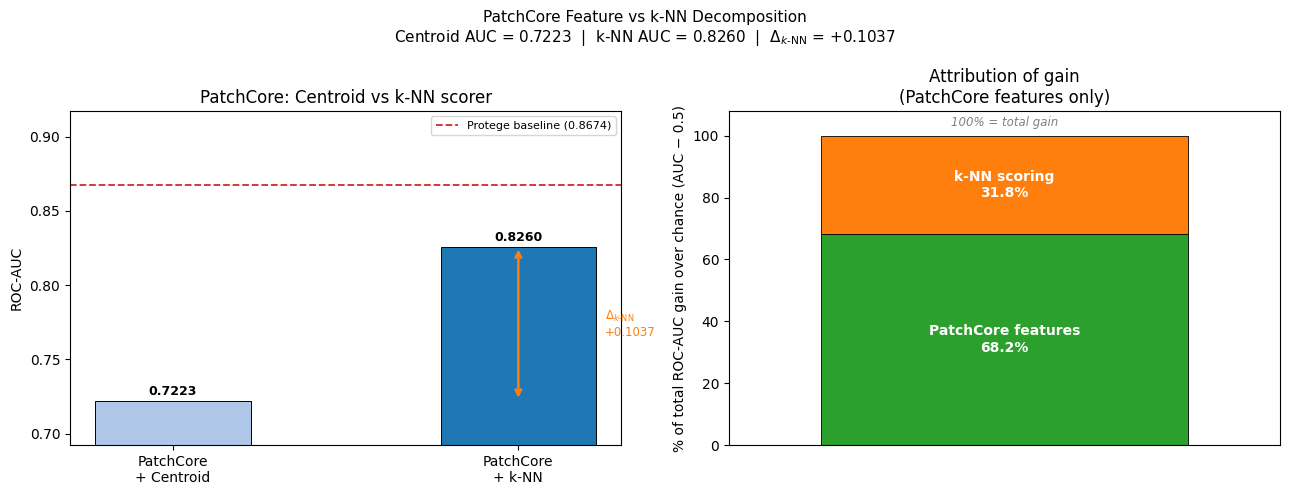

In [36]:
# ── 16.3  Visualise PatchCore feature vs k-NN decomposition ──────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pre-compute the two AUCs we care about
auc_pc_knn      = auc(s_pc_knn)       # PatchCore + k-NN  (full system)
auc_pc_centroid = auc(s_pc_centroid)  # PatchCore + centroid (features only)
protege_auc     = auc(pca_scores_pc)  # Protege ceiling

# Attribution (over-chance baseline = 0.5)
feat_gain  = auc_pc_centroid - 0.5          # what features bring above chance
knn_gain   = auc_pc_knn - auc_pc_centroid   # what k-NN adds on top
total_gain = auc_pc_knn - 0.5              # total gain over chance

feat_pct = 100 * feat_gain  / total_gain if total_gain else 0
knn_pct  = 100 * knn_gain   / total_gain if total_gain else 0

# ── Left: side-by-side bars for the two PatchCore scorers ─────────────────
ax = axes[0]

labels_bar   = ['PatchCore\n+ Centroid', 'PatchCore\n+ k-NN']
auc_vals     = [auc_pc_centroid, auc_pc_knn]
colors_bars  = ['#aec7e8', '#1f77b4']
x = np.arange(len(labels_bar))

bars = ax.bar(x, auc_vals, width=0.45,
              color=colors_bars, edgecolor='k', linewidth=0.7)

# Annotate bars
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., h + 0.002,
            f'{h:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Protege reference line
ax.axhline(protege_auc, color='#d62728', linestyle='--', linewidth=1.3,
           label=f'Protege baseline ({protege_auc:.4f})')

# Annotate the k-NN gain gap with a brace-style arrow
ax.annotate(
    '', xy=(1, auc_pc_knn), xytext=(1, auc_pc_centroid),
    arrowprops=dict(arrowstyle='<->', color='#ff7f0e', lw=1.8)
)
ax.text(1.25, (auc_pc_knn + auc_pc_centroid) / 2,
        f'$\\Delta_{{k\\text{{-NN}}}}$\n{knn_gain:+.4f}',
        va='center', fontsize=8.5, color='#ff7f0e')

ax.set_xticks(x)
ax.set_xticklabels(labels_bar, fontsize=10)
ax.set_ylabel('ROC-AUC')
ax.set_title('PatchCore: Centroid vs k-NN scorer')
ax.legend(fontsize=8)
y_min = min(auc_pc_centroid, auc_pc_knn, protege_auc) - 0.03
y_max = max(auc_pc_centroid, auc_pc_knn, protege_auc) + 0.05
ax.set_ylim(y_min, y_max)

# ── Right: stacked attribution bar (% of total gain over chance) ──────────
ax2 = axes[1]

portions   = [feat_pct, knn_pct]
colors_att = ['#2ca02c', '#ff7f0e']
bar_labels = ['PatchCore features', 'k-NN scoring']

bottom = 0.0
for val, col, lbl in zip(portions, colors_att, bar_labels):
    ax2.bar(0, val, bottom=bottom, color=col, edgecolor='k', linewidth=0.6)
    ax2.text(0, bottom + val / 2,
             f'{lbl}\n{val:.1f}%',
             ha='center', va='center', fontsize=10,
             color='white', fontweight='bold')
    bottom += val

ax2.set_xlim(-0.6, 0.6)
ax2.set_xticks([])
ax2.set_ylabel('% of total ROC-AUC gain over chance (AUC − 0.5)')
ax2.set_title('Attribution of gain\n(PatchCore features only)')
ax2.set_ylim(0, 108)

# Annotate total = 100%
ax2.text(0, 103, '100% = total gain', ha='center', fontsize=8.5,
         color='gray', style='italic')

plt.suptitle(
    f'PatchCore Feature vs k-NN Decomposition\n'
    f'Centroid AUC = {auc_pc_centroid:.4f}  |  '
    f'k-NN AUC = {auc_pc_knn:.4f}  |  '
    f'$\\Delta_{{k\\text{{-NN}}}}$ = {knn_gain:+.4f}',
    fontsize=11
)
plt.tight_layout()
plt.show()

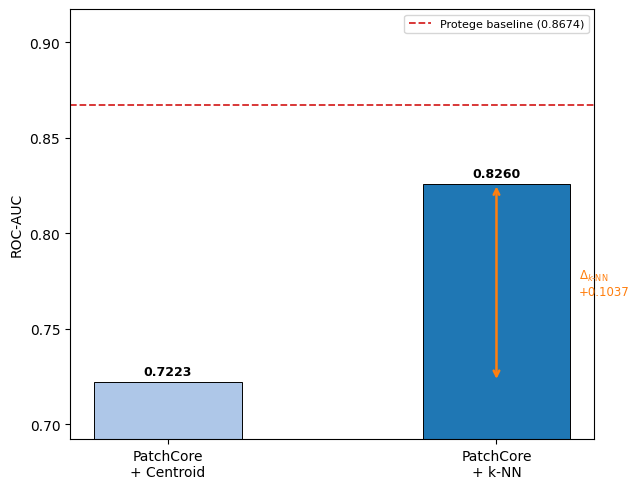

In [37]:
# ── 16.3  Visualise PatchCore feature vs k-NN decomposition ──────────────

fig, ax = plt.subplots(figsize=(6.5, 5))

# Pre-compute the two AUCs we care about
auc_pc_knn      = auc(s_pc_knn)       # PatchCore + k-NN (full system)
auc_pc_centroid = auc(s_pc_centroid)  # PatchCore + centroid
protege_auc     = auc(pca_scores_pc)  # Protege ceiling

# Attribution
knn_gain = auc_pc_knn - auc_pc_centroid

# ── Side-by-side bars for the two PatchCore scorers ──────────────────────
labels_bar  = ['PatchCore\n+ Centroid', 'PatchCore\n+ k-NN']
auc_vals    = [auc_pc_centroid, auc_pc_knn]
colors_bars = ['#aec7e8', '#1f77b4']
x = np.arange(len(labels_bar))

bars = ax.bar(
    x, auc_vals, width=0.45,
    color=colors_bars,
    edgecolor='k',
    linewidth=0.7
)

# Annotate bars
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        h + 0.002,
        f'{h:.4f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Protege reference line
ax.axhline(
    protege_auc,
    color='#d62728',
    linestyle='--',
    linewidth=1.3,
    label=f'Protege baseline ({protege_auc:.4f})'
)

# Annotate k-NN gain
ax.annotate(
    '',
    xy=(1, auc_pc_knn),
    xytext=(1, auc_pc_centroid),
    arrowprops=dict(
        arrowstyle='<->',
        color='#ff7f0e',
        lw=1.8
    )
)

ax.text(
    1.25,
    (auc_pc_knn + auc_pc_centroid) / 2,
    f'$\\Delta_{{k\\text{{-NN}}}}$\n{knn_gain:+.4f}',
    va='center',
    fontsize=8.5,
    color='#ff7f0e'
)

ax.set_xticks(x)
ax.set_xticklabels(labels_bar, fontsize=10)
ax.set_ylabel('ROC-AUC')
#ax.set_title('PatchCore: Centroid vs k-NN scorer')
ax.legend(fontsize=8)

y_min = min(auc_pc_centroid, auc_pc_knn, protege_auc) - 0.03
y_max = max(auc_pc_centroid, auc_pc_knn, protege_auc) + 0.05
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

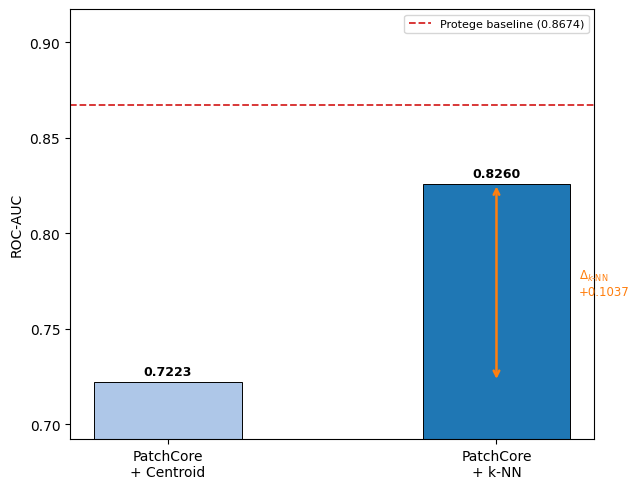

In [38]:
# ── 16.3  Visualise PatchCore feature vs k-NN decomposition ──────────────

fig, ax = plt.subplots(figsize=(6.5, 5))

# Pre-compute the two AUCs we care about
auc_pc_knn      = auc(s_pc_knn)       # PatchCore + k-NN (full system)
auc_pc_centroid = auc(s_pc_centroid)  # PatchCore + centroid
protege_auc     = auc(pca_scores_pc)  # Protege ceiling

# Attribution
knn_gain = auc_pc_knn - auc_pc_centroid

# ── Side-by-side bars for the two PatchCore scorers ──────────────────────
labels_bar  = ['PatchCore\n+ Centroid', 'PatchCore\n+ k-NN']
auc_vals    = [auc_pc_centroid, auc_pc_knn]
colors_bars = ['#aec7e8', '#1f77b4']
x = np.arange(len(labels_bar))

bars = ax.bar(
    x,
    auc_vals,
    width=0.45,
    color=colors_bars,
    edgecolor='k',
    linewidth=0.7
)

# Annotate bars
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        h + 0.002,
        f'{h:.4f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Protege reference line
ax.axhline(
    protege_auc,
    color='#d62728',
    linestyle='--',
    linewidth=1.3,
    label=f'Protege baseline ({protege_auc:.4f})'
)

# Annotate k-NN gain
ax.annotate(
    '',
    xy=(1, auc_pc_knn),
    xytext=(1, auc_pc_centroid),
    arrowprops=dict(
        arrowstyle='<->',
        color='#ff7f0e',
        lw=1.8
    )
)

ax.text(
    1.25,
    (auc_pc_knn + auc_pc_centroid) / 2,
    f'$\\Delta_{{k\\text{{-NN}}}}$\n{knn_gain:+.4f}',
    va='center',
    fontsize=8.5,
    color='#ff7f0e'
)

ax.set_xticks(x)
ax.set_xticklabels(labels_bar, fontsize=10)
ax.set_ylabel('ROC-AUC')
# ax.set_title('PatchCore: Centroid vs k-NN scorer')
ax.legend(fontsize=8)

y_min = min(auc_pc_centroid, auc_pc_knn, protege_auc) - 0.03
y_max = max(auc_pc_centroid, auc_pc_knn, protege_auc) + 0.05
ax.set_ylim(y_min, y_max)

# Remove grid completely
ax.grid(False)
plt.grid(False)

plt.tight_layout()
plt.show()

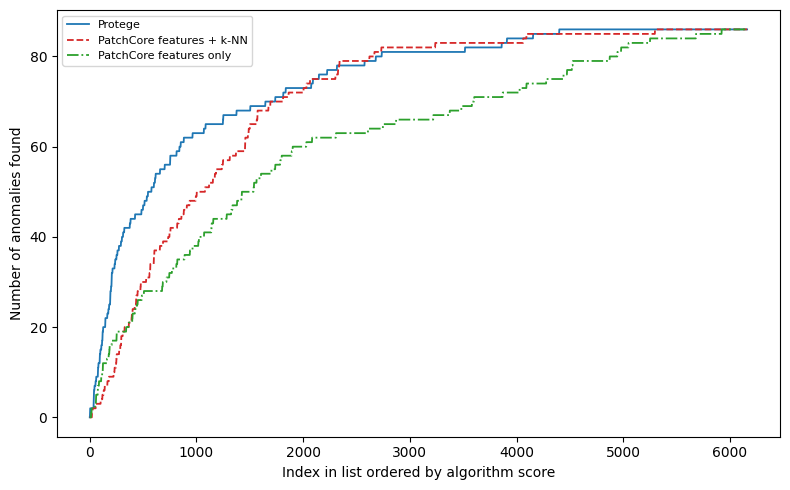

In [39]:
# ── 16.4  Discovery curves — one line per condition ──────────────────────

discovery_plot(
    {
        'Protege':                 pca_scores_pc,
        'PatchCore features + k-NN':     s_pc_knn,
    #    'B: BYOL feats + k-NN':          s_byol_knn,
        'PatchCore features only': s_pc_centroid,
    #    'D: BYOL feats + centroid':      s_byol_centroid,
    },
    y_pc,
    highlight=['PCA (Protege)', 'A: PatchCore feats + k-NN'],
)

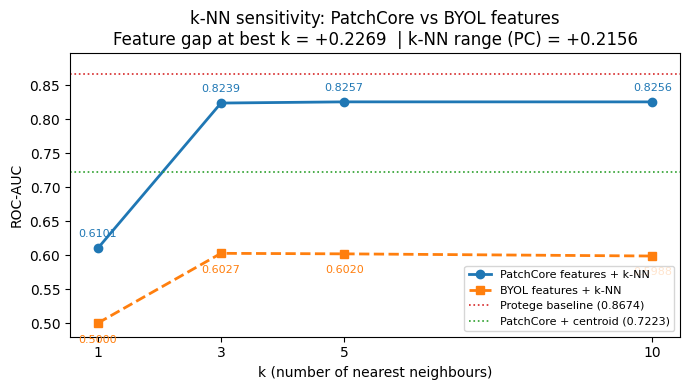


k-NN sensitivity summary (PatchCore features):
  k= 1  ROC-AUC = 0.6101  (+0.0000 vs worst k)
  k= 3  ROC-AUC = 0.8239  (+0.2139 vs worst k)
  k= 5  ROC-AUC = 0.8257  (+0.2156 vs worst k)
  k=10  ROC-AUC = 0.8256  (+0.2156 vs worst k)


In [ ]:
# ── 16.5  k-NN sensitivity: how much does k matter within PatchCore? ─────
#
# If performance is flat across k, the k-NN component itself is not the
# bottleneck — the features are doing all the work.  If there is a sharp
# peak at one k, the scoring strategy matters.

k_vals   = [1, 3, 5, 10]
auc_byol = []
auc_pc   = []

for k in k_vals:
    # PatchCore features
    s_pc = k_scores[k]          # already computed in section 11
    auc_pc.append(roc_auc_score(y_pc, s_pc))

    # BYOL features
    raw  = knn_scores_np(X_byol_white, X_byol_white, k=k)
    s_by = pd.Series(raw, index=eval_ids)
    auc_byol.append(roc_auc_score(y_pc, s_by))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_vals, auc_pc,   'o-', color='#1f77b4', linewidth=2,
        label='PatchCore features + k-NN')
ax.plot(k_vals, auc_byol, 's--', color='#ff7f0e', linewidth=2,
        label='BYOL features + k-NN')
ax.axhline(protege_auc, color='#d62728', linestyle=':', linewidth=1.2,
           label=f'Protege baseline ({protege_auc:.4f})')
ax.axhline(roc_auc_score(y_pc, s_pc_centroid), color='#2ca02c',
           linestyle=':', linewidth=1.2,
           label=f'PatchCore + centroid ({roc_auc_score(y_pc,s_pc_centroid):.4f})')

for xv, yv in zip(k_vals, auc_pc):
    ax.annotate(f'{yv:.4f}', (xv, yv), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8, color='#1f77b4')
for xv, yv in zip(k_vals, auc_byol):
    ax.annotate(f'{yv:.4f}', (xv, yv), textcoords='offset points',
                xytext=(0, -14), ha='center', fontsize=8, color='#ff7f0e')

gap = [pc - by for pc, by in zip(auc_pc, auc_byol)]
ax.set_xlabel('k (number of nearest neighbours)')
ax.set_ylabel('ROC-AUC')
ax.set_title(
    'k-NN sensitivity: PatchCore vs BYOL features\n'
    f'Feature gap at best k = {max(gap):+.4f}  '
    f'| k-NN range (PC) = {max(auc_pc)-min(auc_pc):+.4f}'
)
ax.legend(fontsize=8)
ax.set_xticks(k_vals)
ax.set_ylim(
    min(min(auc_byol), protege_auc) - 0.02,
    max(max(auc_pc),   protege_auc) + 0.03
)
plt.tight_layout()
plt.show()

print()
print('k-NN sensitivity summary (PatchCore features):')
for k, a in zip(k_vals, auc_pc):
    print(f'  k={k:2d}  ROC-AUC = {a:.4f}  '
          f'({a - min(auc_pc):+.4f} vs worst k)')

## 16.6  Interpretation Guide

### Reading the 2×2 grid

| Cell | Features | Scorer | Interpretation |
|------|----------|--------|----------------|
| A | PatchCore | k-NN | Full system — target |
| B | BYOL | k-NN | Same scorer, weaker features → isolates *feature* contribution |
| C | PatchCore | centroid | Better features, naive scorer → isolates *k-NN* contribution |
| D | BYOL | centroid | Both degraded — floor |

**Feature gain** = A − B: how much PatchCore's multi-layer embedding helps *when k-NN scoring is fixed*.

**k-NN gain** = A − C: how much nearest-neighbour scoring helps *when PatchCore features are fixed*.

**Interaction** = (A−D) − feature_gain − knn_gain: positive = the two components amplify each other; negative = they overlap.

### Reading the k-sensitivity plot

- **Flat PC curve** → the k-NN *component* is not a bottleneck; the features are doing the heavy lifting regardless of k.
- **Sharp PC peak** → the right k matters; the scoring strategy contributes meaningfully.
- **Narrow feature gap** (PC ≈ BYOL across all k) → feature quality is not the bottleneck; both backbones encode enough for k-NN to work.
- **Wide feature gap** → PatchCore's multi-scale representation genuinely separates anomalies that BYOL cannot.